In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, f1_score

In [ ]:
data = {
    'product_star_rating': [4.5, 3.2, 4.8, 2.9, 4.0, 4.7, 3.5, 4.9, 2.5, 3.8],
    'product_num_ratings': [1200, 250, 3400, 90, 800, 2700, 400, 3800, 50, 700],
    'product_price': [999, 499, 1299, 299, 899, 1099, 599, 1399, 199, 799],
    'is_prime': [1, 0, 1, 0, 1, 1, 0, 1, 0, 1],
    'climate_pledge_friendly': [1, 0, 1, 0, 0, 1, 0, 1, 0, 0],
    'is_best_seller': [1, 0, 1, 0, 1, 1, 0, 1, 0, 0]
}

In [ ]:
df = pd.DataFrame(data)

print("Dataset Preview:\n", df.head())
print("\nDataset Info:\n")
print(df.info())

Dataset Preview:
    product_star_rating  product_num_ratings  product_price  is_prime  \
0                  4.5                 1200            999         1   
1                  3.2                  250            499         0   
2                  4.8                 3400           1299         1   
3                  2.9                   90            299         0   
4                  4.0                  800            899         1   

   climate_pledge_friendly  is_best_seller  
0                        1               1  
1                        0               0  
2                        1               1  
3                        0               0  
4                        0               1  

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   product_star_rating      10 non-null     float64


In [ ]:
print("\nMissing values per column (before dropping):\n", df.isnull().sum())
df = df.dropna()


Missing values per column (before dropping):
 product_star_rating        0
product_num_ratings        0
product_price              0
is_prime                   0
climate_pledge_friendly    0
is_best_seller             0
dtype: int64


In [ ]:
X = df[['product_star_rating', 'product_num_ratings', 'product_price', 'is_prime', 'climate_pledge_friendly']]
y = df['is_best_seller']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [ ]:
y_pred = model.predict(X_test_scaled)

In [ ]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nModel Evaluation Metrics:")
print(f"  Accuracy: {acc:.2f}")
print(f"  Precision: {prec:.2f}")
print(f"  F1 Score: {f1:.2f}")


Model Evaluation Metrics:
  Accuracy: 1.00
  Precision: 1.00
  F1 Score: 1.00


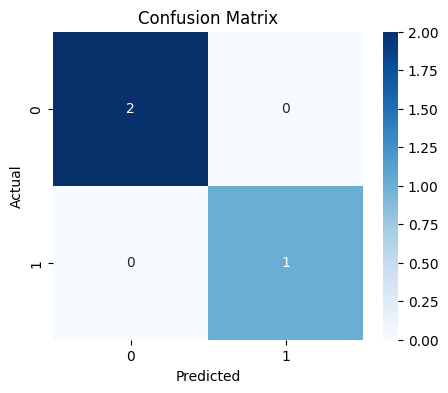

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()